In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:

results = pd.read_csv('simulation_results.csv')
results

,lambda,pt_mean,pt_sigma,num_machine,makespan,mean_wip_source,mean_wip_buffer
0,50,140,10,1,14217,8.32,16.64
1,50,140,10,2,8466,13.98,0.00
2,50,140,10,3,8466,13.98,0.00
3,50,140,10,4,8466,13.98,0.00
4,50,140,10,5,8466,13.98,0.00
...,...,...,...,...,...,...,...
595,90,240,80,1,23501,1.00,27.93
596,90,240,80,2,12029,1.95,11.22
597,90,240,80,3,8698,2.70,0.01
598,90,240,80,4,8698,2.70,0.00


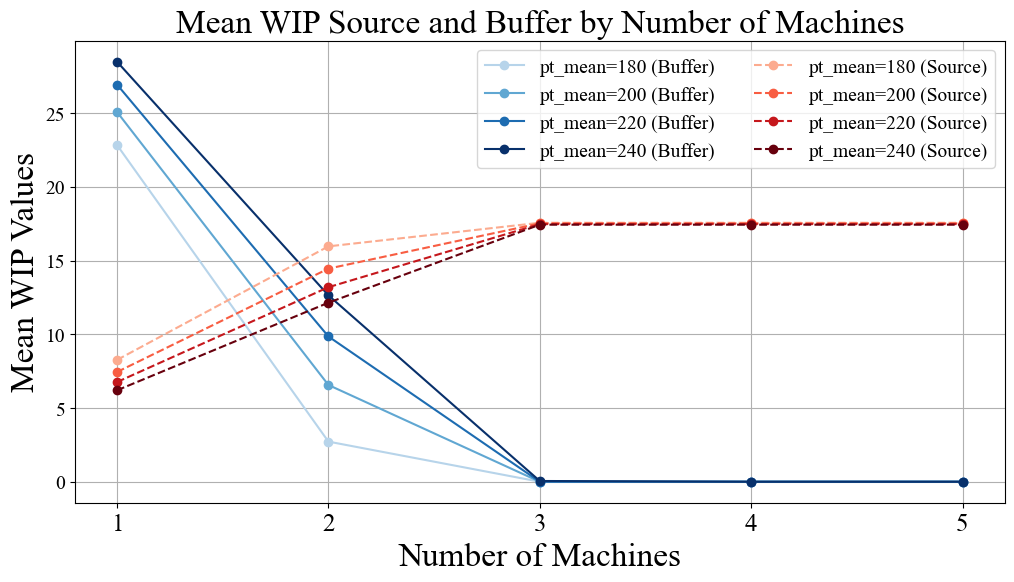

In [21]:
from matplotlib.ticker import MaxNLocator

# 예제 데이터프레임 로드
# 실제 데이터 사용 시 파일 읽기 등을 통해 `results` 데이터프레임을 채워주세요.
# results = pd.read_csv('simulation_results.csv')
SMALL_SIZE = 14
MEDIUM_SIZE = 18
BIGGER_SIZE = 24

plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams.update({'font.size': 14})
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
# 필요한 데이터 추출
results_filtered = results[(results['pt_sigma'] == 40) & (results['pt_mean'] > 170) & (results['lambda'] == 60)]

# `pt_mean`에 따라 색상 지정 (하늘색에서 남색으로 점진적 변화)
pt_means = [180, 200, 220, 240]
colors_b = plt.cm.Blues(np.linspace(0.3, 1, len(pt_means)))
colors_r = plt.cm.Reds(np.linspace(0.3, 1, len(pt_means)))
color_idx = [i for i in range(len(pt_means))]
plt.figure(figsize=(12, 6))
for pt_mean, idx in zip(pt_means, color_idx):
    subset = results_filtered[results_filtered['pt_mean'] == pt_mean]
    if not subset.empty:
        # mean_wip_buffer 플롯
        plt.plot(subset['num_machine'], subset['mean_wip_buffer'], marker='o', linestyle='-', color=colors_b[idx],
                 label=f'pt_mean={pt_mean} (Buffer)')

for pt_mean, idx in zip(pt_means, color_idx):
    subset = results_filtered[results_filtered['pt_mean'] == pt_mean]
    if not subset.empty:
        # mean_wip_source 플롯 (y축 범위 조정 필요 시 별도로 지정)
        plt.plot(subset['num_machine'], subset['mean_wip_source'], marker='o', linestyle='--', color=colors_r[idx],
                 label=f'pt_mean={pt_mean} (Source)')
        
# 축 설정 및 레이블
plt.xlabel('Number of Machines')
plt.ylabel('Mean WIP Values')
plt.title('Mean WIP Source and Buffer by Number of Machines')
plt.legend(loc='upper right', ncol=2)
plt.grid(True)
plt.xticks(fontsize=18)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
# 그래프 표시
# plt.show()
plt.savefig('result.png', dpi=300)

In [7]:
result60 = result[(result['lambda']==60)].copy()

In [8]:
result60

,lambda,pt_mean,pt_sigma,num_machine,makespan,mean_wip_source,mean_wip_buffer
170,60,180,40,1,18006,8.26,22.83
171,60,180,40,2,9316,15.96,2.72
172,60,180,40,3,8470,17.56,0.00
173,60,180,40,4,8470,17.56,0.00
174,60,180,40,5,8470,17.56,0.00
190,60,200,40,1,19998,7.44,25.07
191,60,200,40,2,10291,14.45,6.56
192,60,200,40,3,8490,17.52,0.00
193,60,200,40,4,8490,17.52,0.00
194,60,200,40,5,8490,17.52,0.00
